In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import json as _json
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from plot_style_utils import (
    apply_plot_theme,
    plot_ratio_distribution,
    plot_annotated_bar,
    display_summary_table,
    PALETTE,
)

# =========================
# USER SETTINGS
# =========================
DATA_DIR = Path("../prof_components_extracted")

MIN_YEAR = 2005
MAX_YEAR = 2024

# Revenue filter
MIN_REVENUE = 1.0

# Flagging thresholds for cost_ratio = (COGS + XSGA_COMPONENTS) / REVT
LOW_THRESHOLD = 0.40
HIGH_THRESHOLD = 1.20

# Optional: extreme thresholds for quick diagnostics
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD = 2.00

# Plot settings
TOP_N_EXCHANGES = 15
TOP_N_SECTORS = 15

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR.resolve()}")

apply_plot_theme()

print("Using data from:", DATA_DIR.resolve())


Using data from: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/prof_components_extracted


In [16]:
rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(fp)
    except Exception as e:
        bad_files.append((fp.name, f"read_error: {e}"))
        continue

    if "Year" not in df.columns:
        bad_files.append((fp.name, "missing Year"))
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].copy()

    if df.empty:
        continue

    # fallback identifiers
    if "Ticker" not in df.columns:
        df["Ticker"] = fp.stem
    if "firm" not in df.columns:
        df["firm"] = fp.stem

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded.")

panel = pd.concat(rows, ignore_index=True)

print(f"Loaded rows: {len(panel):,}")
print(f"Unique tickers: {panel['Ticker'].nunique():,}")

if bad_files:
    print("\nSkipped files:")
    for name, reason in bad_files[:20]:
        print(f"- {name}: {reason}")

Loaded rows: 9,774
Unique tickers: 635


In [17]:
required_cols = ["REVT", "COGS", "XSGA_COMPONENTS"]
missing_required = [c for c in required_cols if c not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in required_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["COGS_filled"] = panel["COGS"].fillna(0.0)
panel["XSGA_filled"] = panel["XSGA_COMPONENTS"].fillna(0.0)

panel["REVT_valid"] = panel["REVT"].notna() & (panel["REVT"] > MIN_REVENUE)
panel["TOTAL_COST_PROXY"] = panel["COGS_filled"] + panel["XSGA_filled"]

panel["cost_ratio"] = np.where(
    panel["REVT_valid"],
    panel["TOTAL_COST_PROXY"] / panel["REVT"],
    np.nan
)

# Diagnostics
panel["flag_low"] = panel["cost_ratio"] < LOW_THRESHOLD
panel["flag_high"] = panel["cost_ratio"] > HIGH_THRESHOLD
panel["flag_extreme_low"] = panel["cost_ratio"] < EXTREME_LOW_THRESHOLD
panel["flag_extreme_high"] = panel["cost_ratio"] > EXTREME_HIGH_THRESHOLD

panel["flag_any"] = panel["REVT_valid"] & (panel["flag_low"] | panel["flag_high"])

In [18]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD         = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD        = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD= {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE           = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

print("\nCounts:")
print(f"Total rows           : {n_total:,}")
print(f"Valid ratio rows     : {n_valid:,}")
print(f"Flagged rows         : {n_flagged:,}")
print(f"Low flagged          : {n_low:,}")
print(f"High flagged         : {n_high:,}")

if n_valid > 0:
    print(f"Flagged / valid      : {n_flagged / n_valid:.2%}")
    print(f"Low / valid          : {n_low / n_valid:.2%}")
    print(f"High / valid         : {n_high / n_valid:.2%}")

        cost_ratio
count  9368.000000
mean      1.304151
std       3.908401
min       0.000000
25%       0.779913
50%       0.906464
75%       0.974560
max     106.531661

Thresholds used:
LOW_THRESHOLD         = 0.4
HIGH_THRESHOLD        = 1.2
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD= 2.0
MIN_REVENUE           = 1.0

Counts:
Total rows           : 9,774
Valid ratio rows     : 9,368
Flagged rows         : 1,564
Low flagged          : 607
High flagged         : 957
Flagged / valid      : 16.70%
Low / valid          : 6.48%
High / valid         : 10.22%


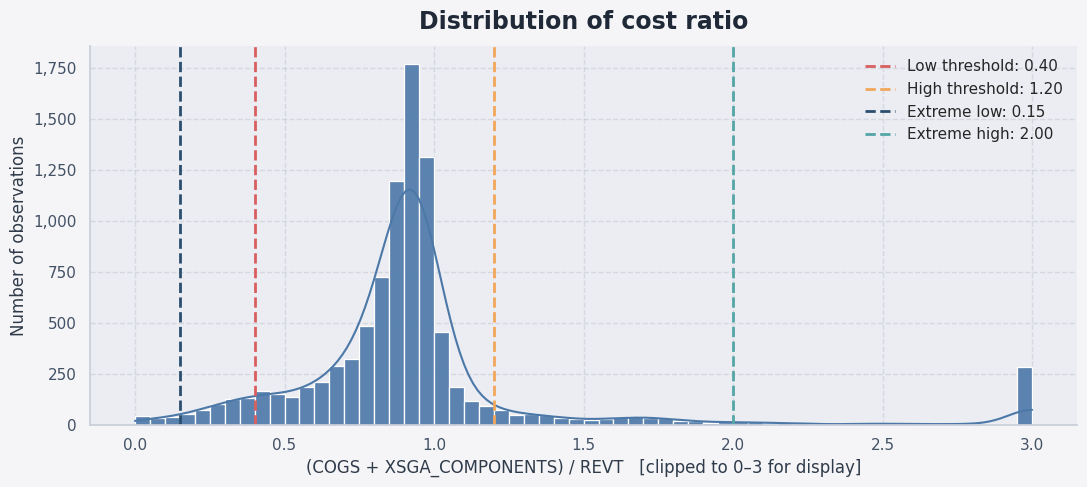

In [19]:
plot_data = panel.loc[panel["cost_ratio"].notna(), "cost_ratio"]

fig, ax = plot_ratio_distribution(
    plot_data,
    low_threshold=LOW_THRESHOLD,
    high_threshold=HIGH_THRESHOLD,
    extreme_low=EXTREME_LOW_THRESHOLD,
    extreme_high=EXTREME_HIGH_THRESHOLD,
)

plt.show()
plt.close(fig)


In [20]:
def extract_exchange(ticker):
    if pd.isna(ticker):
        return "Unknown"
    ticker = str(ticker)
    if "." in ticker:
        return ticker.split(".")[-1]
    return "Unknown"

panel["Exchange"] = panel["Ticker"].apply(extract_exchange)

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


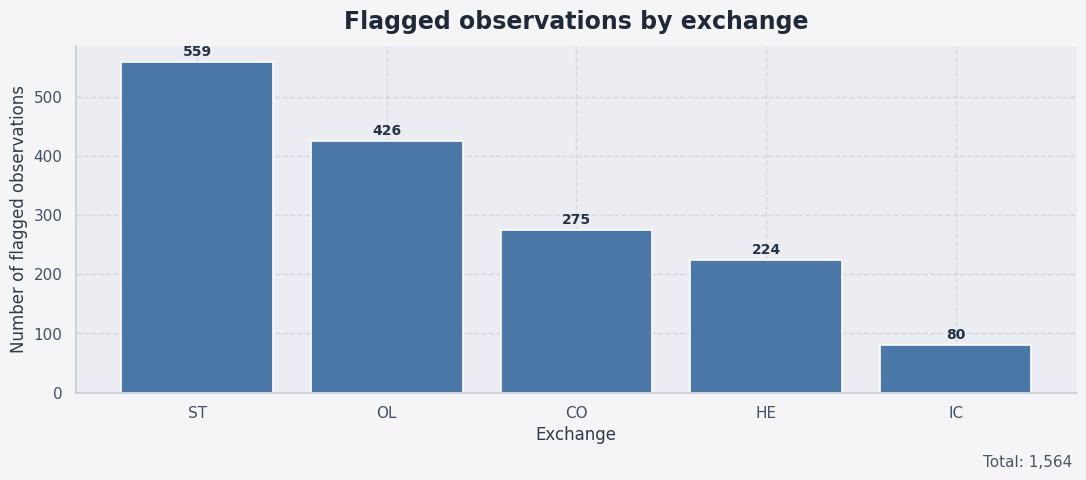

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


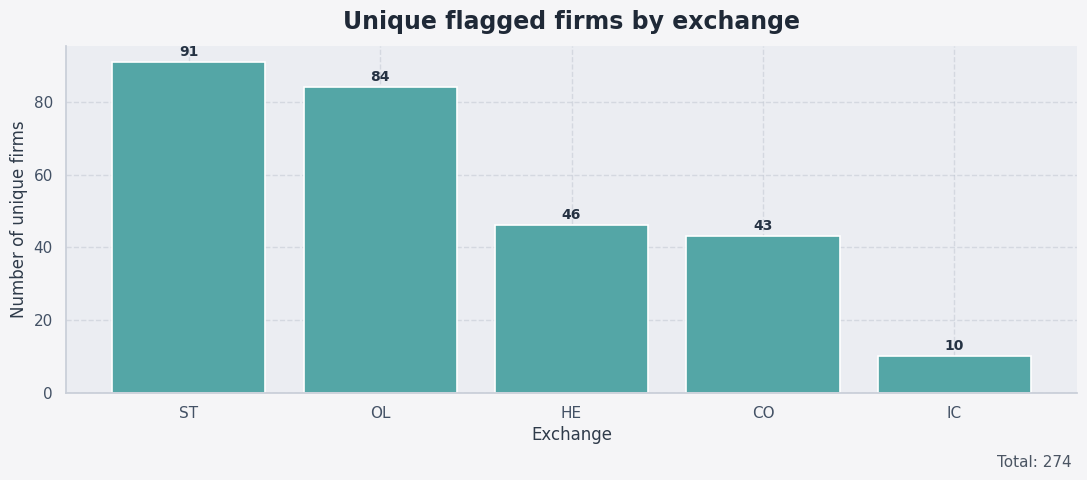

,Exchange,flagged_observations,unique_flagged_firms
0,ST,559,91
1,OL,426,84
2,CO,275,43
3,HE,224,46
4,IC,80,10


In [21]:
flagged = panel.loc[panel["flag_any"]].copy()

exchange_obs = (
    flagged.groupby("Exchange")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

exchange_firms = (
    flagged.groupby("Exchange")["Ticker"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

fig, ax = plot_annotated_bar(
    exchange_obs,
    title="Flagged observations by exchange",
    xlabel="Exchange",
    ylabel="Number of flagged observations",
    color=PALETTE["blue"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
plt.show()

fig, ax = plot_annotated_bar(
    exchange_firms,
    title="Unique flagged firms by exchange",
    xlabel="Exchange",
    ylabel="Number of unique firms",
    color=PALETTE["teal"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
plt.show()

exchange_counts = pd.DataFrame({
    "Exchange": exchange_obs.index,
    "flagged_observations": exchange_obs.values,
    "unique_flagged_firms": exchange_firms.reindex(exchange_obs.index).fillna(0).astype(int).values,
})
display(exchange_counts)


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


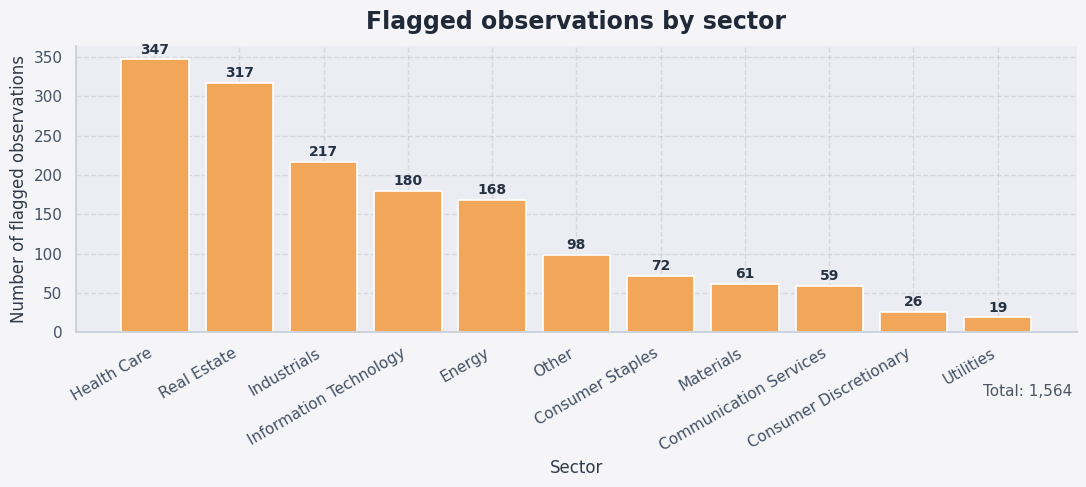

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


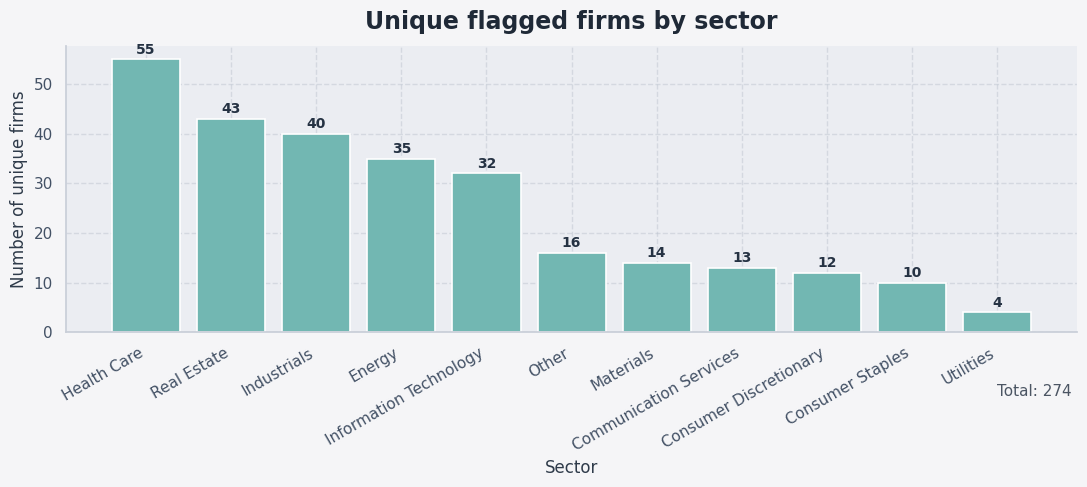

,Sector,flagged_observations,unique_flagged_firms
0,Health Care,347,55
1,Real Estate,317,43
2,Industrials,217,40
3,Information Technology,180,32
4,Energy,168,35
5,Other,98,16
6,Consumer Staples,72,10
7,Materials,61,14
8,Communication Services,59,13
9,Consumer Discretionary,26,12


In [22]:
if "Sector" in flagged.columns:
    sector_obs = (
        flagged.groupby("Sector")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    sector_firms = (
        flagged.groupby("Sector")["Ticker"]
        .nunique()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    fig, ax = plot_annotated_bar(
        sector_obs,
        title="Flagged observations by sector",
        xlabel="Sector",
        ylabel="Number of flagged observations",
        color=PALETTE["orange"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    plt.show()

    fig, ax = plot_annotated_bar(
        sector_firms,
        title="Unique flagged firms by sector",
        xlabel="Sector",
        ylabel="Number of unique firms",
        color=PALETTE["green"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    plt.show()

    sector_counts = pd.DataFrame({
        "Sector": sector_obs.index,
        "flagged_observations": sector_obs.values,
        "unique_flagged_firms": sector_firms.reindex(sector_obs.index).fillna(0).astype(int).values,
    })
    display(sector_counts)
else:
    print("Column 'Sector' not found.")


In [23]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD          = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD         = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD  = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD = {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE            = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

n_unique_firms_total = panel["Ticker"].nunique()
n_unique_firms_valid = panel.loc[panel["REVT_valid"], "Ticker"].nunique()
n_unique_firms_flagged = panel.loc[panel["flag_any"], "Ticker"].nunique()

print("\nCounts:")
print(f"Total rows             : {n_total:,}")
print(f"Valid ratio rows       : {n_valid:,}")
print(f"Flagged rows           : {n_flagged:,}")
print(f"  Low flagged          : {n_low:,}")
print(f"  High flagged         : {n_high:,}")
print(f"Unique firms total     : {n_unique_firms_total:,}")
print(f"Unique firms valid     : {n_unique_firms_valid:,}")
print(f"Unique firms flagged   : {n_unique_firms_flagged:,}")


        cost_ratio
count  9368.000000
mean      1.304151
std       3.908401
min       0.000000
25%       0.779913
50%       0.906464
75%       0.974560
max     106.531661

Thresholds used:
LOW_THRESHOLD          = 0.4
HIGH_THRESHOLD         = 1.2
EXTREME_LOW_THRESHOLD  = 0.15
EXTREME_HIGH_THRESHOLD = 2.0
MIN_REVENUE            = 1.0

Counts:
Total rows             : 9,774
Valid ratio rows       : 9,368
Flagged rows           : 1,564
  Low flagged          : 607
  High flagged         : 957
Unique firms total     : 635
Unique firms valid     : 627
Unique firms flagged   : 274


In [24]:
flag_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Valid ratio rows",
        "Flagged rows",
        "Low flagged rows",
        "High flagged rows",
        "Unique firms total",
        "Unique firms valid",
        "Unique firms flagged",
    ],
    "value": [
        len(panel),
        panel["REVT_valid"].sum(),
        panel["flag_any"].sum(),
        panel["flag_low"].sum(),
        panel["flag_high"].sum(),
        panel["Ticker"].nunique(),
        panel.loc[panel["REVT_valid"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ],
})

display_summary_table(flag_summary)


metric,value
Total rows,"9,774"
Valid ratio rows,"9,368"
Flagged rows,"1,564"
Low flagged rows,607
High flagged rows,957
Unique firms total,635
Unique firms valid,627
Unique firms flagged,274


,observations,unique_companies
flag_type,,
Low,607,123
High,957,187
Total,1564,274


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


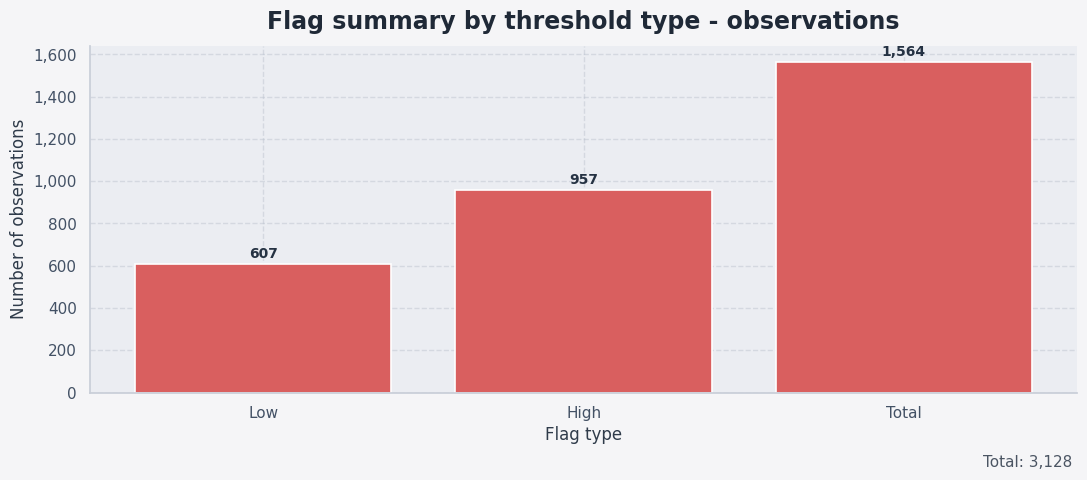

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


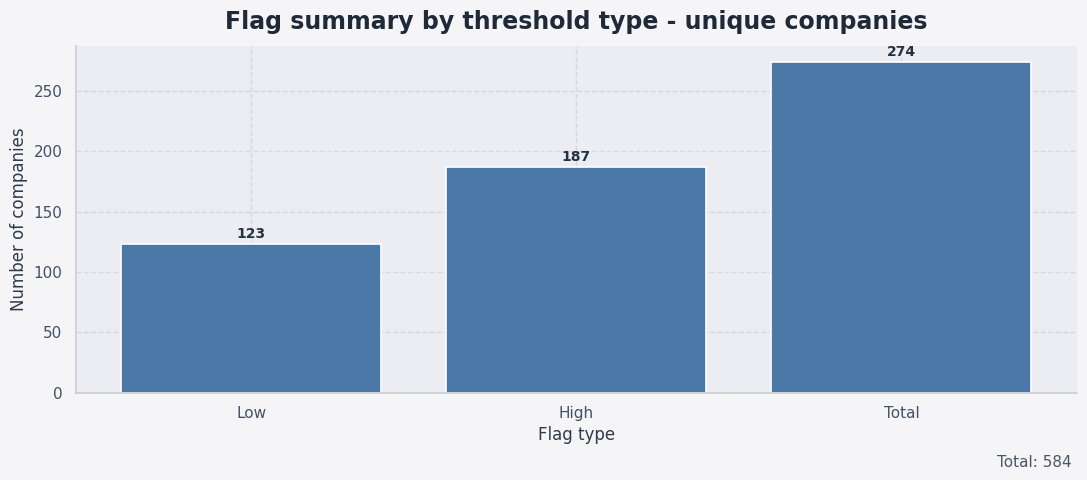

In [25]:
flag_type_counts = pd.DataFrame({
    "flag_type": ["Low", "High", "Total"],
    "observations": [
        int(panel["flag_low"].sum()),
        int(panel["flag_high"].sum()),
        int(panel["flag_any"].sum()),
    ],
    "unique_companies": [
        panel.loc[panel["flag_low"], "Ticker"].nunique(),
        panel.loc[panel["flag_high"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ]
}).set_index("flag_type")

display(flag_type_counts)

fig_obs, ax_obs = plot_annotated_bar(
    flag_type_counts["observations"],
    title="Flag summary by threshold type - observations",
    xlabel="Flag type",
    ylabel="Number of observations",
    color=PALETTE["red"],
    rotation=0,
)
plt.show()

fig_comp, ax_comp = plot_annotated_bar(
    flag_type_counts["unique_companies"],
    title="Flag summary by threshold type - unique companies",
    xlabel="Flag type",
    ylabel="Number of companies",
    color=PALETTE["blue"],
    rotation=0,
)
plt.show()


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_14037/3123407044.py:4: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  valid["flag_category"] = pd.Categorical(


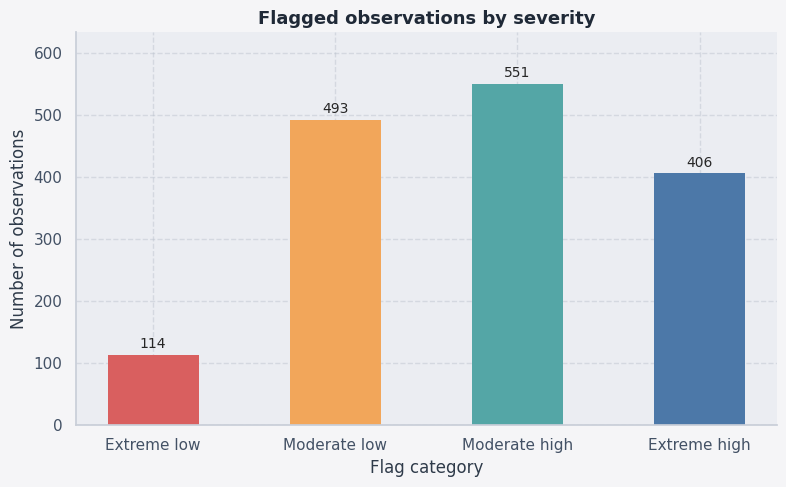

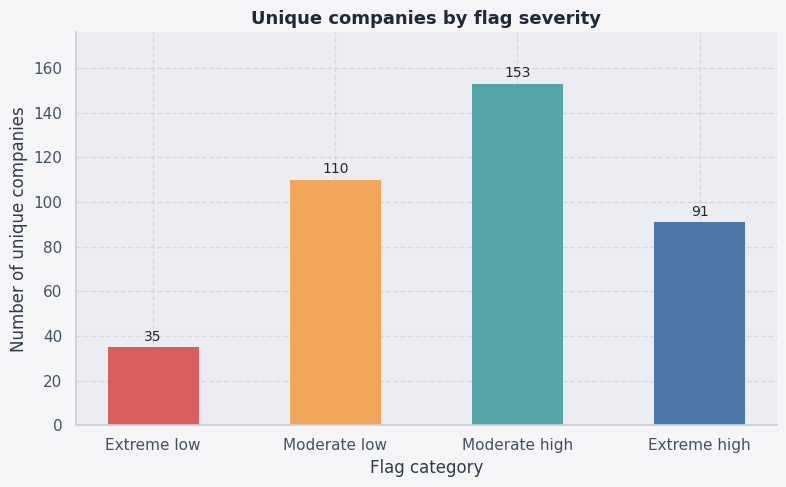

,flag_category,observations,unique_companies
0,Extreme low,114,35
1,Moderate low,493,110
2,Moderate high,551,153
3,Extreme high,406,91


In [26]:
# ── Extreme vs moderate flag breakdown ───────────────────────────────────────
valid = panel.loc[panel["REVT_valid"] & panel["cost_ratio"].notna()].copy()

valid["flag_category"] = pd.Categorical(
    pd.cut(
        valid["cost_ratio"],
        bins=[-np.inf, EXTREME_LOW_THRESHOLD, LOW_THRESHOLD, HIGH_THRESHOLD, EXTREME_HIGH_THRESHOLD, np.inf],
        labels=["Extreme low", "Moderate low", "Normal", "Moderate high", "Extreme high"],
        right=False,
    ),
    categories=["Extreme low", "Moderate low", "Moderate high", "Extreme high"],
    ordered=True,
)

outside = valid.loc[valid["flag_category"].notna()].copy()

CATEGORY_COLORS = {
    "Extreme low":   PALETTE.get("red",    "#d62728"),
    "Moderate low":  PALETTE.get("orange", "#ff7f0e"),
    "Moderate high": PALETTE.get("teal",   "#17becf"),
    "Extreme high":  PALETTE.get("blue",   "#1f77b4"),
}
CATEGORIES = ["Extreme low", "Moderate low", "Moderate high", "Extreme high"]

obs_counts = outside["flag_category"].value_counts().reindex(CATEGORIES, fill_value=0)

fig_obs, ax_obs = plt.subplots(figsize=(8, 5))
bars = ax_obs.bar(
    obs_counts.index, obs_counts.values,
    color=[CATEGORY_COLORS[c] for c in CATEGORIES],
    width=0.5, edgecolor="none",
)
for bar, val in zip(bars, obs_counts.values):
    ax_obs.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(obs_counts.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
ax_obs.set_title("Flagged observations by severity", fontsize=13)
ax_obs.set_xlabel("Flag category")
ax_obs.set_ylabel("Number of observations")
ax_obs.set_ylim(0, max(obs_counts.values) * 1.15)
ax_obs.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig_obs)

firm_counts = (
    outside.groupby("flag_category", observed=True)["Ticker"]
    .nunique()
    .reindex(CATEGORIES, fill_value=0)
)

fig_firms, ax_firms = plt.subplots(figsize=(8, 5))
bars2 = ax_firms.bar(
    firm_counts.index, firm_counts.values,
    color=[CATEGORY_COLORS[c] for c in CATEGORIES],
    width=0.5, edgecolor="none",
)
for bar, val in zip(bars2, firm_counts.values):
    ax_firms.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + max(firm_counts.values) * 0.01,
                  f"{val:,}", ha="center", va="bottom", fontsize=10)
ax_firms.set_title("Unique companies by flag severity", fontsize=13)
ax_firms.set_xlabel("Flag category")
ax_firms.set_ylabel("Number of unique companies")
ax_firms.set_ylim(0, max(firm_counts.values) * 1.15)
ax_firms.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig_firms)

severity_table = pd.DataFrame({
    "flag_category": CATEGORIES,
    "observations": obs_counts.values,
    "unique_companies": firm_counts.values,
})
display(severity_table)


In [ ]:
# ── 1. Classify flag type ────────────────────────────────────────────────────
flagged = panel.loc[panel["flag_any"]].copy()

flagged["flag_type"] = np.select(
    [
        flagged["flag_low"] & flagged["flag_high"],
        flagged["flag_low"],
        flagged["flag_high"],
    ],
    ["Both", "Low", "High"],
    default="Not flagged",
)

# ── 2. Add extreme/moderate severity ────────────────────────────────────────
is_extreme = (
    (flagged["cost_ratio"] < EXTREME_LOW_THRESHOLD) |
    (flagged["cost_ratio"] > EXTREME_HIGH_THRESHOLD)
)
flagged["severity"] = np.where(is_extreme, "Extreme", "Moderate")

# ── 3. Extract exchange suffix ───────────────────────────────────────────────
EXCHANGE_ORDER = ["ST", "IC", "CO", "HE", "OL"]

flagged["exchange_suffix"] = (
    flagged["Ticker"].str.split(".").str[-1].str.upper().fillna("ZZ")
)

order_map = {s: i for i, s in enumerate(EXCHANGE_ORDER)}
flagged["exchange_order"] = (
    flagged["exchange_suffix"].map(order_map).fillna(len(EXCHANGE_ORDER)).astype(int)
)

# ── 4. Load reviewed tickers from mappings JSON files ───────────────────────
MAPPINGS_DIR = Path("../mappings")
reviewed_tickers = set()

CR_TAGS = {"CR:c", "CR:nc"}
flagged_tickers = set(flagged["Ticker"].dropna().unique())

def is_reviewed(json_path):
    try:
        with open(json_path) as f:
            data = _json.load(f)
        for var in data.get("variables", []):
            notes = var.get("notes", "")
            if isinstance(notes, str):
                first_token = notes.strip().split("|")[0].strip()
                if first_token in CR_TAGS:
                    return True
    except Exception:
        pass
    return False

if MAPPINGS_DIR.exists():
    for json_file in MAPPINGS_DIR.rglob("*.json"):
        if json_file.stem not in flagged_tickers:
            continue
        if is_reviewed(json_file):
            reviewed_tickers.add(json_file.stem)
else:
    print(f"Warning: mappings directory not found at {MAPPINGS_DIR.resolve()}")

print(f"Tickers marked as reviewed (CR:c / CR:nc): {len(reviewed_tickers)}")

# ── 5. Filter out reviewed tickers ──────────────────────────────────────────
flagged = flagged.loc[~flagged["Ticker"].isin(reviewed_tickers)].copy()
print(f"Rows after filtering reviewed tickers: {len(flagged):,}")

# ── 6. Build final sorted table ──────────────────────────────────────────────
show_cols = [
    "Ticker", "CompanyName", "Year", "Exchange", "Industry", "Sector",
    "REVT", "COGS", "XSGA_COMPONENTS", "TOTAL_COST_PROXY",
    "cost_ratio", "flag_type", "severity",
]
show_cols = [c for c in show_cols if c in flagged.columns]

flagged_table = (
    flagged
    .sort_values(["exchange_order", "Ticker"], ascending=[True, True])
    .reset_index(drop=True)
)[show_cols]

# ── 7. Display single scrollable table ──────────────────────────────────────
display(
    HTML(
        "<div style='max-height:600px; overflow-y:auto'>"
        + flagged_table.to_html(index=False, max_rows=None, max_cols=None)
        + "</div>"
    )
)
print(f"Total rows shown: {len(flagged_table):,}")
print(f"Unique firms: {flagged_table['Ticker'].nunique():,}")


Tickers marked as reviewed (CR:c / CR:nc): 190
Rows after filtering reviewed tickers: 410


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
SAGCV.HE,Saga Furs Oyj,2012,HE,Textiles & Apparel,Other,458.85,0.00,182.15,182.15,0.396971,Low,Moderate
SAGCV.HE,Saga Furs Oyj,2020,HE,Textiles & Apparel,Other,299.34,14.79,438.16,452.95,1.513162,High,Moderate
SOSI1.HE,Sotkamo Silver AB,2008,HE,Metals & Mining,Materials,2.86,0.00,104.99,104.99,36.709790,High,Extreme
SOSI1.HE,Sotkamo Silver AB,2013,HE,Metals & Mining,Materials,1.31,0.00,3.94,3.94,3.007634,High,Extreme
SSH1V.HE,SSH Communications Security Oyj,2005,HE,Software & IT Services,Information Technology,74.46,0.68,96.90,97.58,1.310502,High,Moderate
SSH1V.HE,SSH Communications Security Oyj,2008,HE,Software & IT Services,Information Technology,70.00,0.00,89.77,89.77,1.282429,High,Moderate
SSH1V.HE,SSH Communications Security Oyj,2011,HE,Software & IT Services,Information Technology,62.79,1.09,77.58,78.67,1.252907,High,Moderate
SSH1V.HE,SSH Communications Security Oyj,2015,HE,Software & IT Services,Information Technology,168.76,58.08,149.80,207.88,1.231808,High,Moderate
SSH1V.HE,SSH Communications Security Oyj,2016,HE,Software & IT Services,Information Technology,140.45,17.88,222.45,240.33,1.711143,High,Moderate
SSH1V.HE,SSH Communications Security Oyj,2020,HE,Software & IT Services,Information Technology,120.65,3.04,154.85,157.89,1.308661,High,Moderate


Total rows shown: 410


In [28]:
# display(
#     HTML(
#         flagged_table.to_html(index=False, max_rows=200, max_cols=None)
#     )
# )


In [29]:
# display(flagged_table)


In [30]:
# low_flagged = flagged_table.loc[flagged_table["flag_type"] == "Low"].reset_index(drop=True)
# high_flagged = flagged_table.loc[flagged_table["flag_type"] == "High"].reset_index(drop=True)

# print(f"Low flagged rows : {len(low_flagged):,}")
# print(f"High flagged rows: {len(high_flagged):,}")

# display(low_flagged.head(50))
# display(high_flagged.head(50))


In [31]:
# Plots are shown inline above — no export needed.